# <div style="padding: 30px;color:white;margin:10;font-size:60%;text-align:left;display:fill;border-radius:10px;background-color:#FFFFFF;overflow:hidden;background-color:#3b3745"><b><span style='color:#F1A424'>1 |</span></b> <b>BACKGROUND</b></div>



### <b><span style='color:#F1A424'> 1.1 |</span> Context</b> 

The CalCOFI data set represents the longest (1949-present) and most complete (more than 50,000 sampling stations) time series of oceanographic and larval fish data in the world. It includes abundance data on the larvae of over 250 species of fish; larval length frequency data and egg abundance data on key commercial species; and oceanographic and plankton data. The physical, chemical, and biological data collected at regular time and space intervals quickly became valuable for documenting climatic cycles in the California Current and a range of biological responses to them. CalCOFI research drew world attention to the biological response to the dramatic Pacific-warming event in 1957-58 and introduced the term “El Niño” into the scientific literature.

CalCOFI conducts quarterly cruises off southern & central California, collecting a suite of hydrographic and biological data on station and underway. Data collected at depths down to 500 m include: temperature, salinity, oxygen, phosphate, silicate, nitrate and nitrite, chlorophyll, transmissometer, PAR, C14 primary productivity, phytoplankton biodiversity, zooplankton biomass, and zooplankton biodiversity.

### <b><span style='color:#F1A424'> 1.2 |</span> Scope</b>

We would like to know if a connection between Salinity and Temperature exists



# <div style="padding: 30px;color:white;margin:10;font-size:60%;text-align:left;display:fill;border-radius:10px;background-color:#FFFFFF;overflow:hidden;background-color:#3b3745"><b><span style='color:#F1A424'>2 |</span></b> <b>REFERENCE LINKS</b></div>

Main Website: https://calcofi.com/ <br>
Bottle-Dataset: https://new.data.calcofi.com/index.php/database/calcofi-database/bottle-field-descriptions <br>
Cast-Dataset: https://new.data.calcofi.com/index.php/database/calcofi-database/cast-table-column-descriptions


# <div style="padding: 30px;color:white;margin:10;font-size:60%;text-align:left;display:fill;border-radius:10px;background-color:#FFFFFF;overflow:hidden;background-color:#3b3745"><b><span style='color:#F1A424'>3 |</span></b> <b>EDA (EXPLORATION DATA ANALYSIS)</b></div>

### <b><span style='color:#F1A424'> 3.1 |</span> Import Packages and Datasets</b> 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import seaborn as sns
import plotly.express as px
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor

In [ ]:
bot=pd.read_csv('/kaggle/input/calcofi/bottle.csv',low_memory=False)#.to_csv('bottlecsv.csv')
cast=pd.read_csv('/kaggle/input/calcofi/cast.csv',low_memory=False)#.to_csv('castcsv.csv')

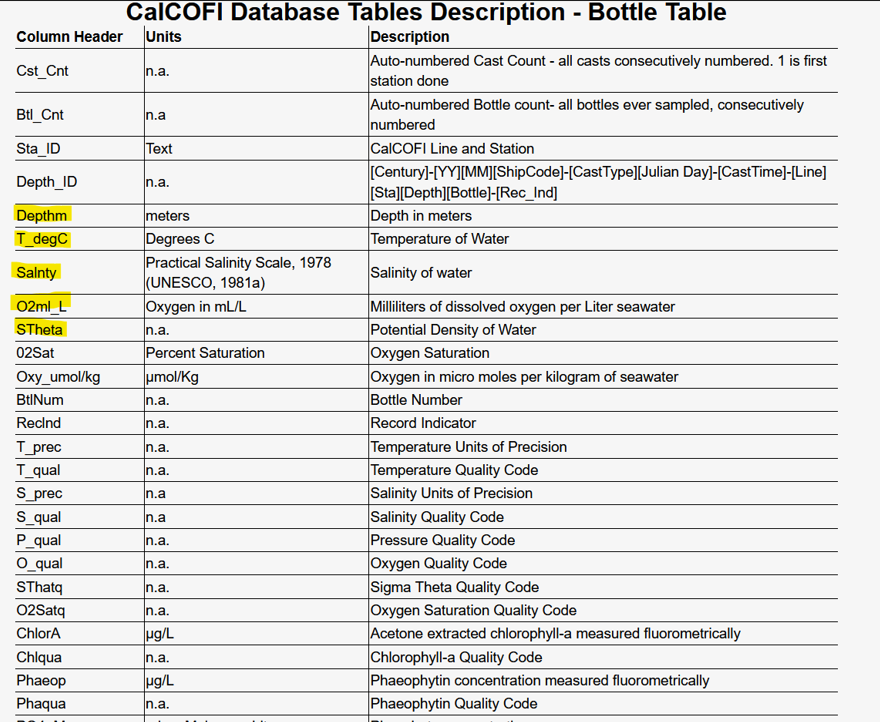

In [ ]:
bot.info()

**It has been decided to reduce the dataset to the following features:**

In [ ]:
bottle=bot.iloc[:,[0,4,5,6,7,8]]
bottle

In [ ]:
bottle.info()

### <b><span style='color:#F1A424'> 3.2 |</span> NAN VALUES ANALYSIS</b> 

<div style="color:white;display:fill;border-radius:8px;font-size:120%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#F1A424;text-align:center'>Nan Values Visualization </span></b></p></div> 

In [ ]:
plt.rcParams["figure.figsize"] = (8,5)
sns.heatmap(bottle.isna(),cbar=False,cmap='viridis')

<div style="color:white;display:fill;border-radius:8px;font-size:120%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#F1A424;text-align:center'>Data cleaning </span></b></p></div> 

In [ ]:
cols=bottle.columns

for colonna in cols:
    bottle=bottle[~bottle[colonna].isnull()]

In [ ]:
bottle=bottle.reset_index(drop=True)
plt.rcParams["figure.figsize"] = (8,5)
sns.heatmap(bottle.isna(),cbar=False,cmap='viridis')

### <b><span style='color:#F1A424'> 3.3 |</span> CORRELATION MATRIX</b> 

In [ ]:
plt.figure(figsize=(10,5))
mask = np.triu(np.ones_like(bottle.corr(numeric_only = True), dtype=bool))
sns.heatmap(bottle.corr(numeric_only = True), cbar = True, annot = True, cmap="viridis", mask = mask);

The Pearson's coefficient between Temperature and Salinity is not so high, -0.51

### <b><span style='color:#F1A424'> 3.4 |</span> FEATURES PLOTS</b> 

Plot pairwise relationships in the dataset

In [ ]:
sns.pairplot(bottle)

### <b><span style='color:#F1A424'> 3.5 |</span> DEPTH - TEMPERATURE - SALINITY </b> 

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(20,5))
g1=sns.scatterplot(data=bottle,x='Depthm',y='T_degC',ax=ax[0])
ax[0].set(xlabel='Depth [m]',ylabel='Temperature [°C]',title='Temperature vs Depth')
ax[0].grid()
g2=sns.scatterplot(data=bottle,x='Depthm',y='Salnty',ax=ax[1])
ax[1].set(xlabel='Depth [m]',ylabel='Salinity',title='Salinity vs Depth')
ax[1].grid()


As we can see from the image above temperature and salinity trace a hyperbolic trend as depth changes:

- In the first plot some points in the upper part of the image show a different trend from the rest of the graph. It's an unexpected behavior, because, for instance, at around 1000 m depth the expected temperature is around 5°C, but we also find temperatures between 10°C and 15°C (https://www.windows2universe.org/earth/Water/temp.html)

- In the second plot we can notice that the points converge asymptotically from both high and low salinity values. It means that in some areas of the ocean the salinity encreases with the depth, vice versa in other areas it decreases. 

<div style="color:white;display:fill;border-radius:8px;font-size:120%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#F1A424;text-align:center'>Distribution of Measuring Points on Geograph Datamap</span></b></p></div>

Here we show the measuring points on the map using latitude and longitude informations.

In [ ]:
df_merge=bottle.merge(cast, how='inner',on='Cst_Cnt')

In [ ]:
fig = px.scatter_mapbox(df_merge, 
                        lat="Lat_Dec", 
                        lon="Lon_Dec",
                        #hover_name="Address", 
                        hover_data=["Depthm"],
                        color="T_degC",
                        #color_continuous_scale=color_scale,
                        #size="Listed",
                        #animation_frame='Year',
                        zoom=3, 
                        height=800,
                        width=800)

#fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(
    mapbox_style="white-bg",
    mapbox_layers=[
        {
            "below": 'traces',
            "sourcetype": "raster",
            "sourceattribution": "United States Geological Survey",
            "source": [
                "https://basemap.nationalmap.gov/arcgis/rest/services/USGSImageryOnly/MapServer/tile/{z}/{y}/{x}"
            ]
        }])
fig.show()

If we isolate points with salinity values in the range going from 34.85 to 38 we observe our alternative trend highlighted in the Temperature-Depth graph. It came out!

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(20,5))
bottle_filter=bottle[(bottle['Salnty']>34.85)&(bottle['Salnty']<38)]
g1=sns.scatterplot(data=bottle,x='Depthm',y='T_degC',ax=ax[0])
g1=sns.scatterplot(data=bottle_filter,x='Depthm',y='T_degC',ax=ax[0],legend=None,alpha=0.7)
ax[0].set(xlabel='Depth [m]',ylabel='Temperature [°C]',title='Temperature vs Depth')
ax[0].grid()
g2=sns.scatterplot(data=bottle,x='Depthm',y='Salnty',ax=ax[1])
g2=sns.scatterplot(data=bottle_filter,x='Depthm',y='Salnty',ax=ax[1],alpha=0.7)
ax[1].set(xlabel='Depth [m]',ylabel='Salinity',title='Salinity vs Depth')
ax[1].grid()

<div style="color:white;display:fill;border-radius:8px;font-size:120%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#F1A424;text-align:center'>Distribution of Measuring Points for filtered dataset</span></b></p></div>

Then we show the measuring points from the filtered dataset in the specific salinity range: 34.85 - 38.

In [ ]:
df_merge_filter=bottle_filter.merge(cast, how='inner',on='Cst_Cnt')

fig = px.scatter_mapbox(df_merge_filter, 
                        lat="Lat_Dec", 
                        lon="Lon_Dec",
                        #hover_name="Address", 
                        hover_data=["Depthm","Salnty","Cst_Cnt"],
                        color="T_degC",
                        #color_continuous_scale=color_scale,
                        #size="Listed",
                        #animation_frame='Year',
                        zoom=5, 
                        height=800,
                        width=800)

#fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(
    mapbox_style="white-bg",
    mapbox_layers=[
        {
            "below": 'traces',
            "sourcetype": "raster",
            "sourceattribution": "United States Geological Survey",
            "source": [
                "https://basemap.nationalmap.gov/arcgis/rest/services/USGSImageryOnly/MapServer/tile/{z}/{y}/{x}"
            ]
        }])
fig.show()

We note that most points with high salinity values are located in the gulf.

### <b><span style='color:#F1A424'> 3.6 |</span> SALINITY - TEMPERATURE </b> 

In [ ]:
plt.rcParams['figure.figsize']=10,6
ax=sns.scatterplot(data=bottle,x='Salnty',y='T_degC')
ax.set(xlabel='Salinity',ylabel='Temperature',title='Salinity vs Temperature')
plt.grid()

Salinity and Temperature don't seem to have a strong relationship. 

We can try to use some additional information using the potential density (https://en.wikipedia.org/wiki/Potential_density).
Remind that potential density is not a measured but a calculated quantity from Temperature, Pressure and Salinity. 

Thanks to proportional link between chlorine and salinity, the last one (difficult to measure) is calculated through the measurement of chlorine, using an electrical conductivity meter.

The technology used to measure Conductivity, Temperature, and Pressure (related to Depth) at the same time in seawater is called CTD (https://en.wikipedia.org/wiki/CTD_(instrument))


<div style="color:white;display:fill;border-radius:8px;font-size:120%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#F1A424;text-align:center'>Salinity-Temperature and potential Density plot</span></b></p></div> 

As predicted by the theoretical model, Temperature can be expressed as a function of Salinity and Density:

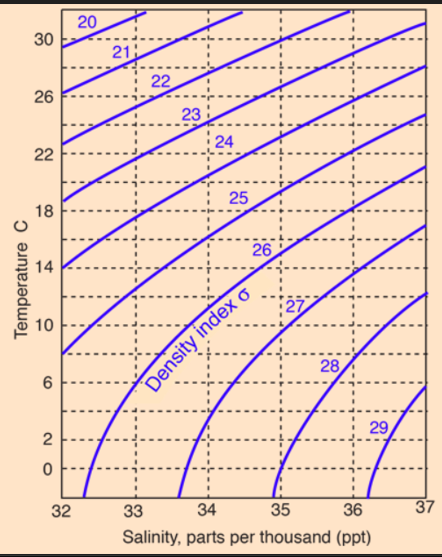

We can try to highlight the density variable on the same graph:

In [ ]:
theta_step=[20,23,24,25,26,27,34]
plt.rcParams['figure.figsize']=10,6

for theta1, theta2 in zip(theta_step, theta_step[1:]):
    bottle_stheta=bottle[(bottle['STheta']>=theta1) & (bottle['STheta']<theta2)]
    sns.scatterplot(data=bottle_stheta,y='T_degC',x='Salnty',label=str(theta1)+'-'+str(theta2))
   
plt.grid()

It works! But remind, it's not the real density at the specific depth, it's a potential density.

# <div style="padding: 30px;color:white;margin:10;font-size:60%;text-align:left;display:fill;border-radius:10px;background-color:#FFFFFF;overflow:hidden;background-color:#3b3745"><b><span style='color:#F1A424'>4 |</span></b> <b>PREDICTIVE MODELS</b></div>

<div style="color:white;display:fill;border-radius:8px;font-size:120%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#F1A424;text-align:center'>Split Train - Test </span></b></p></div>

In [ ]:
### Split
bottle_train, bottle_test = train_test_split(bottle, test_size=0.2, random_state=1234)

print("bottle_train: ", bottle_train.shape)
print("bottle_test: ", bottle_test.shape,"\n")

#features =['Salnty','STheta']
features =bottle.columns.drop('T_degC').tolist()
target = 'T_degC'
X_train = bottle_train[features].values
y_train = bottle_train[target].values
X_test = bottle_test[features].values
y_test = bottle_test[target].values

### <b><span style='color:#F1A424'> 4.1 |</span> LINEAR REGRESSION</b> 

<div style="color:white;display:fill;border-radius:8px;font-size:120%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#F1A424;text-align:center'>Temperature from Salinity </span></b></p></div>

In [ ]:
features1=['Salnty'] #only Salinity feature
X_train1 = bottle_train[features1].values
y_train1 = bottle_train[target].values
X_test1 = bottle_test[features1].values
y_test1 = bottle_test[target].values

# creazione modello regressione lineare
model = LinearRegression()
model.fit(X_train1,y_train1)
y_predict1 = model.predict(X_test1)

<div style="color:white;display:fill;border-radius:8px;font-size:120%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#F1A424;text-align:center'>Linear Regression Error </span></b></p></div>

In [ ]:
#calcolo errore modello di regressione
print(model)
mse_lin=mean_squared_error(y_test1, y_predict1)
RMSE_lin=mse_lin**(1/2.0)

print('RMSE_lin:',RMSE_lin)

<div style="color:white;display:fill;border-radius:8px;font-size:120%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#F1A424;text-align:center'>Linear Regression Plot </span></b></p></div>

In [ ]:
g2=sns.regplot(x='Salnty',y="T_degC",data=bottle, color="red")
sns.scatterplot(data=bottle,x='Salnty',y='T_degC')
g2.set(xlabel='Salinity', ylabel='Temperature',title='Linear Regression')

It doesn't seem to exist a clear trend. It's consistently with the -0.5 Pearson's coefficient got from the confusion matrix. The linear regression is inversely proportional, but it doesn't seem a strong correlation. Of course we isolated the feature of Salinity from the others. We could try to use it with other phisical quantities that we've maintained in this work

<div style="color:white;display:fill;border-radius:8px;font-size:120%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#F1A424;text-align:center'>Multiple Linear Regression </span></b></p></div>

In [ ]:
# creazione modello regressione lineare
model = LinearRegression()
model.fit(X_train,y_train)
print(model)
y_predict2 = model.predict(X_test)

#calcolo errore modello di regressione
mse_multilin=mean_squared_error(y_test, y_predict2)
RMSE_multilin=mse_multilin**(1/2.0)

print('RMSE_multilin:',RMSE_multilin)


Much better

### <b><span style='color:#F1A424'> 4.2 |</span> REGRESSION TREE </b> 

In [ ]:
model_tree = DecisionTreeRegressor(random_state=44,max_depth=10)
model_tree.fit(X_train, y_train)
predictions = model_tree.predict(X_test)

In [ ]:
plt.figure(figsize=(10,10))
#plot decision tree depth=4
tree.plot_tree(model_tree,feature_names=features,filled=True,max_depth=2);

<div style="color:white;display:fill;border-radius:8px;font-size:120%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#F1A424;text-align:center'>Regression Tree Error </span></b></p></div>

In [ ]:
mse_tree = mean_squared_error(y_test, predictions) 
RMSE_tree= mse_tree**(1/2)
#print("MSE: ", mse_tree) 
print("RMSE_tree: ", RMSE_tree)

### <b><span style='color:#F1A424'> 4.3 |</span> KNN</b> 

In [ ]:
k=100
model = KNeighborsRegressor(n_neighbors=k)
print(model)

model.fit(X_train,y_train)

pred_y = model.predict(X_test)

<div style="color:white;display:fill;border-radius:8px;font-size:120%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#F1A424;text-align:center'>KNN Error </span></b></p></div>

In [ ]:
print(model)
mse_knn = mean_squared_error(y_test, pred_y)
RMSE_knn = mse_knn**(1/2) 
print("RMSE_KNN: ", RMSE_knn)

KNN alghoritm is worse than multilinear regressor and decision tree regressor. 

### <b><span style='color:#F1A424'> 4.4 |</span> FEATURE IMPORTANCE ANALYSIS</b> 

We can get a feature importance analysis through the decision tree model used above 

In [ ]:
for i,feature in enumerate(features):
    print('',feature,'=', model_tree.feature_importances_[i])

In [ ]:
pd.Series(model_tree.feature_importances_[1:5] , index=['Depth','Salinity','Oxygen','Density']).nlargest(4).plot(kind='barh',figsize=(10,4))

Density (STheta=0.919) and Salinity (Salnty=0.061) have the higher feature importance as shown in the theoretical model

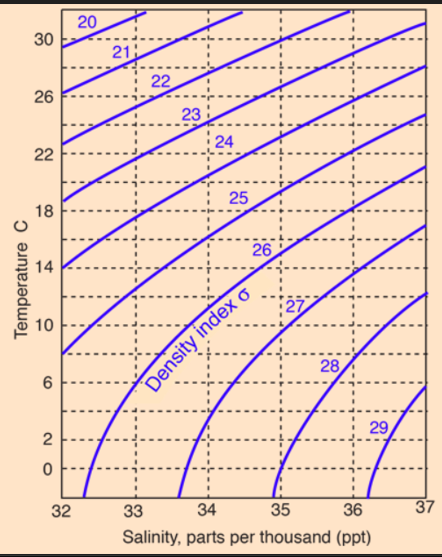

So, we can try to repeat our predictions using only these forementioned two features

In [ ]:
features2=['Salnty','STheta'] #only Salinity and Density features
X_train2 = bottle_train[features2].values
y_train2 = bottle_train[target].values
X_test2 = bottle_test[features2].values
y_test2 = bottle_test[target].values

# MULTIPLE LINEAR REGRESSION
model = LinearRegression()
model.fit(X_train2,y_train2)
y_predict2 = model.predict(X_test2)

#print(model)
#calcolo errore modello di regressione
mse_multilin=mean_squared_error(y_test2, y_predict2)
RMSE_multilin_2f=mse_multilin**(1/2.0)

print('RMSE_multilin_2f:',RMSE_multilin_2f)

#DECISION TREE
model = DecisionTreeRegressor(random_state=44,max_depth=10)
model.fit(X_train2, y_train2)
#print(model)
predictions = model.predict(X_test2)
mse_tree = mean_squared_error(y_test2, predictions) 
RMSE_tree_2f= mse_tree**(1/2)
#print("MSE: ", mse_tree) 
print("RMSE_tree_2f: ", RMSE_tree_2f)

#KNN
k=100
model = KNeighborsRegressor(n_neighbors=k)
model.fit(X_train2,y_train2)
pred_y = model.predict(X_test2)
#print(model)
mse_knn = mean_squared_error(y_test2, pred_y)
RMSE_knn_2f = mse_knn**(1/2) 
print("RMSE_KNN_2f: ", RMSE_knn_2f)

#linear regression with density
features3=['STheta'] #only Salinity and Density features
X_train3 = bottle_train[features3].values
y_train3 = bottle_train[target].values
X_test3 = bottle_test[features3].values
y_test3 = bottle_test[target].values

# LINEAR REGRESSION with density
model = LinearRegression()
model.fit(X_train3,y_train3)
y_predict3 = model.predict(X_test3)

#calcolo errore modello di regressione per densità
mse_lin_dens=mean_squared_error(y_test3, y_predict3)
RMSE_lin_dens=mse_lin_dens**(1/2.0)
print("RMSE_dens: ", RMSE_lin_dens)


<div style="color:white;display:fill;border-radius:8px;font-size:120%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#F1A424;text-align:center'>RMSE Plot</span></b></p></div>

In [ ]:
Metodo_g1 = ['MultiLin','Tree','KNN']
Metodo_g2 = ['MultiLin', 'Tree','KNN']
Metodo_g3 = ['Lin']
Metodo_g4 = ['Lin']
RMSE_g1 = [RMSE_multilin_2f,RMSE_tree_2f,RMSE_knn_2f ]
RMSE_g2 = [RMSE_multilin, RMSE_tree,RMSE_knn]
RMSE_g3 = [RMSE_lin]
RMSE_g4 = [RMSE_lin_dens]

#setup figure
fig, ax = plt.subplots(1,4, figsize=(20,5))
g1=sns.barplot(x=Metodo_g1, y=RMSE_g1,ax=ax[3])
g2=sns.barplot(x=Metodo_g2, y=RMSE_g2,ax=ax[2])
g3=sns.barplot(x=Metodo_g3, y=RMSE_g3,ax=ax[0])
g4=sns.barplot(x=Metodo_g4, y=RMSE_g4,ax=ax[1])
g1.set_title('Prediction with Density and Salinity')
g2.set_title('Prediction with 5 features')
g3.set_title('Prediction with Salinity only')
g4.set_title('Prediction with Density only')
g1.set_ylim(0, 3.7)
g1.set_ylabel('RMSE')
g2.set_ylim(0, 3.7)
g2.set_ylabel('RMSE')
g3.set_ylim(0, 3.7)
g3.set_ylabel('RMSE')
g4.set_ylim(0, 3.7)
g4.set_ylabel('RMSE')
#g2.set_title('Boxplot della Densità')
plt.show()

# <div style="padding: 30px;color:white;margin:10;font-size:60%;text-align:left;display:fill;border-radius:10px;background-color:#FFFFFF;overflow:hidden;background-color:#3b3745"><b><span style='color:#F1A424'>5 |</span></b> <b>CONCLUSION</b></div>

1. Apparently there isn't a strong relationship between Temperature and Salinity as shown in the picture on the right ('Prediction with Salinity only')
2. In order to enhance the temperature prediction with the linear regression model we need to use more features (the picture in the middle): Salinity, Density, Oxygen Saturation,Depth
3. KNN model shows better results when we use the only features with a higher importance: Density and Salinity. The same features introduced from the theoretical model on Temperature-Salinity-Density

<div style="color:white;display:fill;border-radius:8px;font-size:120%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#F1A424;text-align:center'>Last but not least...</span></b></p></div>

Below some plots to give a graphic explanation of why by adding the density feature we are able to improve the error.

One feature as Salinity is not enough to find a link with Temperature. A simple straight line is not able to describe a trend of a dependent variable (Temperature) function of two indipendent variables (Density and Salinity). 

Instead adding one or more degrees of freedoms (i.e. Density) we give useful informations to our predictive model.

<div style="color:white;display:fill;border-radius:8px;font-size:120%; letter-spacing:1.0px;"><p style="padding: 5px;color:white;text-align:left;"><b><span style='color:#F1A424;text-align:center'>Temperature - Salinity- Density </span></b></p></div>

In [ ]:
theta_step=[20,23,24,25,26,27,34]
fig = plt.figure(figsize=[10,12])
ax = fig.add_subplot(projection='3d')

# set axis labels
ax.set_xlabel('\nTemperature')
ax.set_ylabel('\nSalinity')
ax.set_zlabel('\nDensity', linespacing=3.4)

for theta1, theta2 in zip(theta_step, theta_step[1:]):
    bottle_stheta=bottle[(bottle['STheta']>=theta1) & (bottle['STheta']<theta2)]
    ax.scatter(bottle_stheta['T_degC'], bottle_stheta['Salnty'], bottle_stheta['STheta'].values.reshape(-1,1))
   
plt.grid()
plt.gca().invert_zaxis()
plt.gca().view_init(-150, 30)


In [ ]:
features3=['Salnty','STheta'] 
X_train3 = bottle_train[features3].values
y_train3 = bottle_train[target].values

model = LinearRegression()
model.fit(X_train3,y_train3)

#interpolazione dei punti del piano
N=10
x_mesh = np.linspace(30, 37, N)   # intervalli sull'asse della salinità
y_mesh = np.linspace(20, 30,N)  # intervalli sull'asse della densità
xx_pred, yy_pred = np.meshgrid(x_mesh, y_mesh)
model_viz = np.array([xx_pred.flatten(), yy_pred.flatten()]).T

predicted = model.predict(model_viz) # Valori di temperatura 

 The result of the linear regression is no longer a straight line, but a plane

In [ ]:
fig = plt.figure(figsize=(10,12))
ax = fig.add_subplot(projection='3d') #crea immagine 3D

# set axis labels
ax.set_xlabel('\nTemperature')
ax.set_ylabel('\nSalinity')
ax.set_zlabel('\nDensity', linespacing=3.4)

ax.plot_trisurf(predicted, xx_pred.flatten(), yy_pred.flatten(), linewidth=0,alpha=0.6)  # plot piano di regressione
ax.set_xlim(0,30)
ax.set_ylim(30,37)
ax.set_zlim(21,28)

#Visualizzazione con view: -170,40
plt.gca().view_init(-170, 40)
plt.gca().invert_zaxis()

# plot punti del dataframe Bottle
for theta1, theta2 in zip(theta_step, theta_step[1:]):
    bottle_stheta=bottle[(bottle['STheta']>=theta1) & (bottle['STheta']<theta2)]
    ax.scatter(bottle_stheta['T_degC'], bottle_stheta['Salnty'], bottle_stheta['STheta'].values.reshape(-1,1))

In [ ]:
fig = plt.figure(figsize=(10,12))
ax = fig.add_subplot(projection='3d')

# set axis labels
ax.set_xlabel('\nTemperature')
ax.set_ylabel('\nSalinity')
ax.set_zlabel('\nDensity', linespacing=3.4)

ax.plot_trisurf(predicted, xx_pred.flatten(), yy_pred.flatten(), linewidth=0,alpha=0.3)  # plot piano di regressione
ax.set_xlim(0,30)
ax.set_ylim(30,37)
ax.set_zlim(21,28)

#Visualizzazione con view: -170,30
plt.gca().view_init(-170, 30)
plt.gca().invert_zaxis()
# plot punti del dataframe Bottle 
for theta1, theta2 in zip(theta_step, theta_step[1:]):
    bottle_stheta=bottle[(bottle['STheta']>=theta1) & (bottle['STheta']<theta2)]
    ax.scatter(bottle_stheta['T_degC'], bottle_stheta['Salnty'], bottle_stheta['STheta'].values.reshape(-1,1))

Note: of course it's not a complete work, we know a hyperparameter optimization is missing, or a scientific approach to filter the right features, etc, etc. On Kaggle other colleagues have made these contributions that we suggest to consult. We hope you will find it useful.

***This work was a sharing project by Angelo Sorge, Davide Fichera and Mattia Giurisato***. 

***If you like it, if you have comments, or other ideas about it let us know.***